# Issue #3 — Mob Wife Aesthetic: How Fast Did It Die?

**Pillar:** 2 (trend cycle speed)

**Story:** Trend cycles feel instant now, but "instant" is vague. This issue puts a real number on it:
using the mob wife aesthetic (viral January 2024) as a case study, how long does a fashion trend
actually take to go from everywhere to nowhere? And once the hype's gone, what happens to the actual
products it was built on?

**Scope locked:**
- Data: Google Trends, US-only, one representative trend ("mob wife aesthetic") + a related product
  term ("leopard print coat")
- Timeframe: Nov 2023-present, full window, with visual emphasis on the crash
- Cost beat: Depop resale price snapshot (current pricing, not before/after) + general fast-fashion
  waste stats (context only)

## 1. Setup

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import json
from pathlib import Path
from datetime import datetime
from trendspy import Trends
from pytrends.request import TrendReq

ISSUE = "issue-03"
DATA_OUT = Path(f"../../data/processed/issue-03-hot-take-cold-coat")
CHART_OUT = Path(f"../../content/posts/issue-03-hot-take-cold-coat/exports")
DATA_OUT.mkdir(parents=True, exist_ok=True)
CHART_OUT.mkdir(parents=True, exist_ok=True)

## 2. Load palette

In [7]:
# load brand palette
with open("../../brand/palette.json") as f:
    palette_data = json.load(f)

palette = {c["name"]: c["hex"] for c in palette_data["palette"]}

COCOA = palette["Cocoa"]
DUSTY = palette["Dusty"]
PEACH = palette["Peach"]
CREAM = palette["Cream"]
SAGE  = palette["Sage"]

plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["axes.facecolor"] = CREAM
plt.rcParams["figure.facecolor"] = CREAM

## 3. Data pull

In [10]:
# pull google trends data
# trendspy handles google's current cookie/session flow correctly
tr = Trends()

TERM_AESTHETIC = "mob wife aesthetic"
TERM_PRODUCT = "leopard print coat"

df = tr.interest_over_time(
    [TERM_AESTHETIC, TERM_PRODUCT],
    timeframe="2023-11-01 2026-08-07",
    geo="US"
)

trends_df = df

# drop the final partial (still-in-progress) week if present, it may show a misleading dip
if "isPartial" in trends_df.columns:
    trends_df = trends_df[trends_df["isPartial"] == False].drop(columns=["isPartial"])

trends_df.to_csv(DATA_OUT / "google_trends_raw.csv")
trends_df.tail()

,mob wife aesthetic,leopard print coat
time [UTC],,
2026-06-28,0,0
2026-07-05,0,3
2026-07-12,0,4
2026-07-19,0,1
2026-07-26,1,3


## 4. Seasonality check

Fur/leopard coat search terms carry natural winter seasonality regardless of any trend. Before
locking the product term, plot both lines and check whether the product term shows repeated winter
bumps in years *without* the trend (e.g. winter 2024–25, 2025–26). If so, either:
- swap to a less seasonal product term, or
- note the seasonality explicitly in `sources.md` and account for it in the chart annotation.

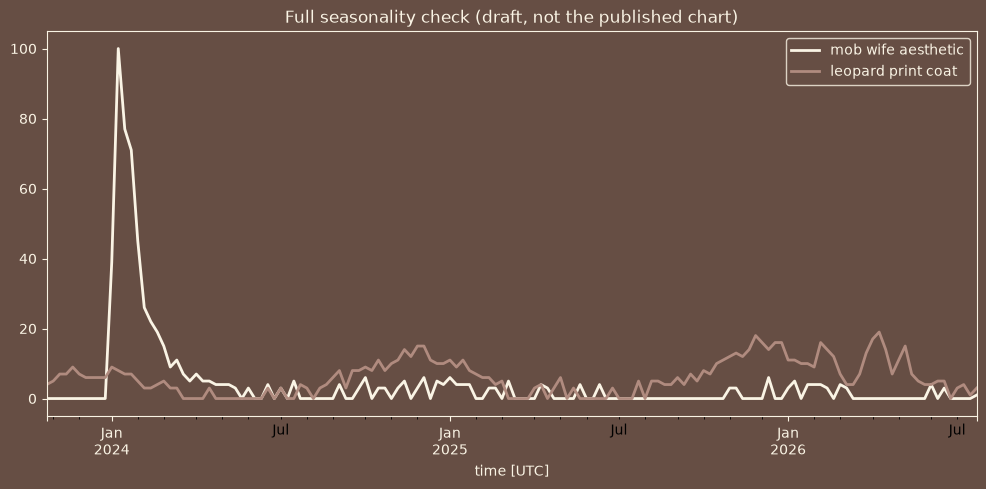

In [17]:
# Full seasonality check
fig, ax = plt.subplots(figsize=(12, 5))
fig.patch.set_facecolor(COCOA)
ax.set_facecolor(COCOA)

trends_df[TERM_AESTHETIC].plot(ax=ax, color=CREAM, linewidth=2, label=TERM_AESTHETIC)
trends_df[TERM_PRODUCT].plot(ax=ax, color=DUSTY, linewidth=2, label=TERM_PRODUCT)

ax.legend(facecolor=COCOA, edgecolor=CREAM, labelcolor=CREAM)
ax.set_title("Full seasonality check (draft, not the published chart)", color=CREAM)

ax.tick_params(colors=CREAM)
ax.xaxis.label.set_color(CREAM)
ax.yaxis.label.set_color(CREAM)
for spine in ax.spines.values():
    spine.set_color(CREAM)

plt.show()

## 5. Manual inputs

Figures are unable to be programatically pulled. Each one is screenshot and dated; log in `sources.md`.

In [18]:
manual_inputs = {
    "hashtag_views": {
        "value": 100_000_000,
        "label": "#mobwife hashtag views",
        "source": "Refinery29, Jan 19 2024",
        "source_url": "https://www.refinery29.com/en-us/mob-wife-aesthetic-fashion-trend-tiktok",
        "date_accessed": "2026-08-07",
    },
    "depop_resale_snapshot": {
        "items_checked": ["faux fur coat", "leopard print coat"],
        "listing_count": {"faux fur coat": 20_400, "leopard print coat": 3_780},
        "price_range_aud": {
                "faux fur coat": {"full": (15, 1500), "typical": (40, 100)},
                "leopard print coat": {"full": (20, 1000), "typical": (50, 150)},
        },
        "price_range_usd": {
            "faux fur coat": {"full": (11, 1055), "typical": (28, 70)},
            "leopard print coat": {"full": (14, 703), "typical": (35, 105)},
        },
        "conversion_rate": {"rate": 0.7030, "pair": "1 AUD = 0.7030 USD", "date": "2026-08-07"},
        "date_accessed": "2026-08-07",
        "screenshot_paths": {
            "faux fur coat": f"../../sources/screenshots/issue-03/depop_fauxfur.webp",
            "leopard print coat": f"../../sources/screenshots/issue-03/depop_leopard.webp",
        },
        "notes": "No historical Depop pricing available (platform doesn't retain past listings), so this"
                 "is a current-pricing snapshot, not a before/after collapse. Framing: these pieces are still "
                 "readily available and still affordable, right now, well after the trend's search interest "
                 "died. High-end outliers (AU$1K-1.5K) are likely vintage/designer pieces, not representative, "
                 "lead with the 'typical' range on the slide, keep 'full' range in sources.md only."
    },
    "waste_context_stat": {
        "value": "1 garbage truck of textiles landfilled or burned every second",
        "secondary_value": "$500 billion in value lost yearly to clothing that's barely worn, rarely recycled",
        "label": "Global textile waste (context only, not mob-wife-specific)",
        "source": "Ellen MacArthur Foundation, A New Textiles Economy: Redesigning Fashion's Future (2017)",
        "source_url": "https://www.ellenmacarthurfoundation.org/news/one-garbage-truck-of-textiles-wasted-every-second-report-creates-vision-for-change",
        "report_year": 2017,
        "date_accessed": "2026-08-07",
        "note": "General fast-fashion waste statistic used as CONTEXT ONLY. Do not present as "
                "trend-specific evidence. Flag the 2017 report year on the slide citation so it doesn't "
                "read as current data.",
    },
}

manual_inputs

{'hashtag_views': {'value': 100000000,
  'label': '#mobwife hashtag views',
  'source': 'Refinery29, Jan 19 2024',
  'source_url': 'https://www.refinery29.com/en-us/mob-wife-aesthetic-fashion-trend-tiktok',
  'date_accessed': '2026-08-07'},
 'depop_resale_snapshot': {'items_checked': ['faux fur coat',
   'leopard print coat'],
  'listing_count': {'faux fur coat': 20400, 'leopard print coat': 3780},
  'price_range_aud': {'faux fur coat': {'full': (15, 1500),
    'typical': (40, 100)},
   'leopard print coat': {'full': (20, 1000), 'typical': (50, 150)}},
  'price_range_usd': {'faux fur coat': {'full': (11, 1055),
    'typical': (28, 70)},
   'leopard print coat': {'full': (14, 703), 'typical': (35, 105)}},
  'conversion_rate': {'rate': 0.703,
   'pair': '1 AUD = 0.7030 USD',
   'date': '2026-08-07'},
  'date_accessed': '2026-08-07',
  'screenshot_paths': {'faux fur coat': '../../sources/screenshots/issue-03/depop_fauxfur.webp',
   'leopard print coat': '../../sources/screenshots/issue-03

## 6. Analysis and plotting

### 6.1 Analysis

- Identify peak week for the aesthetic term.
- Calculate weeks/months from peak to a defined "faded" threshold (e.g. <20% of peak interest).
- Compare aesthetic-term decay speed to product-term decay speed (if product term is kept).

In [19]:
peak_date = trends_df[TERM_AESTHETIC].idxmax()
peak_value = trends_df[TERM_AESTHETIC].max()
threshold = peak_value * 0.20

post_peak = trends_df.loc[peak_date:]
faded_date = post_peak[post_peak[TERM_AESTHETIC] <= threshold].index.min()

weeks_to_fade = None
if pd.notnull(faded_date):
    weeks_to_fade = (faded_date - peak_date).days / 7

print(f"Peak: {peak_date.date()} (value={peak_value})")
print(f"Faded to <20% of peak by: {faded_date.date() if pd.notnull(faded_date) else 'not yet'}")
print(f"Weeks from peak to faded: {weeks_to_fade}")

Peak: 2024-01-14 (value=100)
Faded to <20% of peak by: 2024-02-25
Weeks from peak to faded: 6.0


In [28]:
# winter peak comparison for the product term
winter_windows = {
    "Winter 2023-24": ("2023-11-01", "2024-02-28"),
    "Winter 2024-25": ("2024-11-01", "2025-02-28"),
    "Winter 2025-26": ("2025-11-01", "2026-02-28"),
}

winter_peaks = {
    label: trends_df.loc[start:end, TERM_PRODUCT].max()
    for label, (start, end) in winter_windows.items()
}

print(winter_peaks)

{'Winter 2023-24': np.int64(9), 'Winter 2024-25': np.int64(15), 'Winter 2025-26': np.int64(18)}


### 6.2 Charting

Full window (Nov 2023 - present) with visual emphasis on the Noc 2023 - Dec 2024 crash window, per locked scope (zoomed inset or annotated segment, not a cropped chart).

#### Chart 1: Hero line, "mob wife aesthetic" search interest

Single-line chart for THE STAT slide. Shows the full rise-and-fall shape with peak and
fade-to-under-20% annotated directly. No product-term overlay here, that comparison lives
in its own chart below to avoid the winter-seasonality confound bleeding into the hook visual.

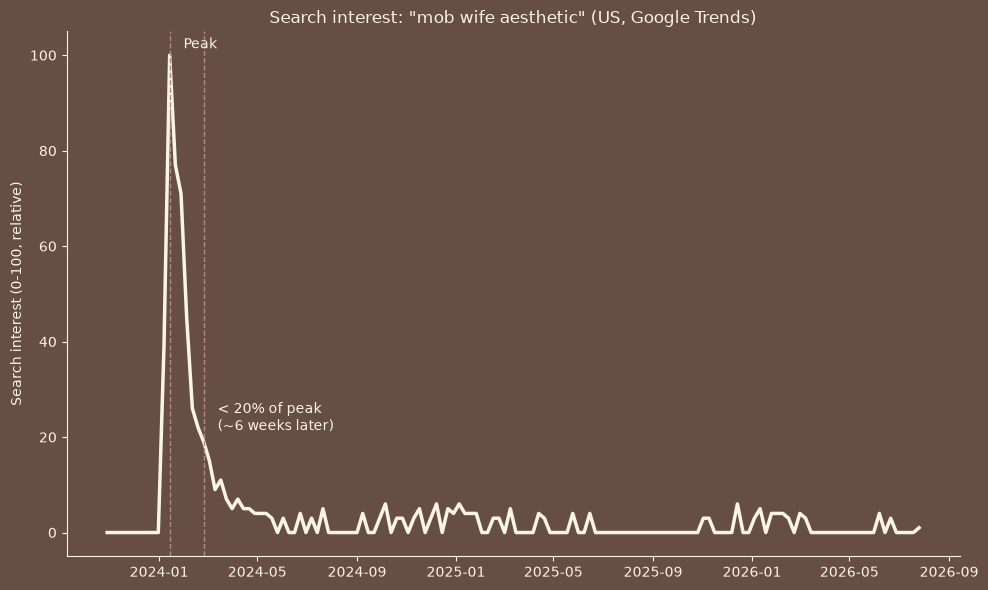

In [30]:
fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor(COCOA)
ax.set_facecolor(COCOA)

ax.plot(trends_df.index, trends_df[TERM_AESTHETIC], color=CREAM, linewidth=2.5)

ax.axvline(peak_date, color=DUSTY, linestyle="--", linewidth=1)
ax.annotate("Peak", xy=(peak_date, peak_value), xytext=(10, 5),
            textcoords="offset points", color=CREAM)

if pd.notnull(faded_date):
    ax.axvline(faded_date, color=DUSTY, linestyle="--", linewidth=1)
    label = f"< 20% of peak\n(~{weeks_to_fade:.0f} weeks later)" if weeks_to_fade else "Faded"
    ax.annotate(label, xy=(faded_date, threshold), xytext=(10, 5),
                textcoords="offset points", color=CREAM)

ax.set_title('Search interest: "mob wife aesthetic" (US, Google Trends)', color=CREAM)
ax.set_ylabel("Search interest (0-100, relative)", color=CREAM)
ax.tick_params(colors=CREAM)

ax.spines[["top", "right"]].set_visible(False)
ax.spines["left"].set_color(CREAM)
ax.spines["bottom"].set_color(CREAM)

plt.tight_layout()
plt.savefig(CHART_OUT / "trends_curve_hero.png", dpi=300, facecolor=COCOA)
plt.show()

#### Chart 2: "Leopard print coat" winter search peaks

Supporting visual for a later slide (label vs. product beat). Compares peak search interest
for the product term across each winter in the window, isolates the seasonal pattern from the
trend's own spike so it reads as its own finding rather than noise on the hero chart.

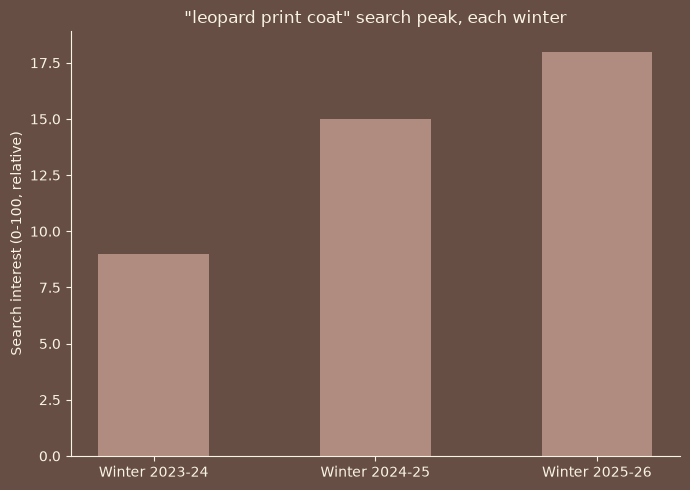

{'Winter 2023-24': np.int64(9), 'Winter 2024-25': np.int64(15), 'Winter 2025-26': np.int64(18)}


In [31]:
fig, ax = plt.subplots(figsize=(7, 5))
fig.patch.set_facecolor(COCOA)
ax.set_facecolor(COCOA)

ax.bar(winter_peaks.keys(), winter_peaks.values(), color=DUSTY, width=0.5)

ax.set_title(f'"{TERM_PRODUCT}" search peak, each winter', color=CREAM)
ax.set_ylabel("Search interest (0-100, relative)", color=CREAM)
ax.tick_params(colors=CREAM)

ax.spines[["top", "right"]].set_visible(False)
ax.spines["left"].set_color(CREAM)
ax.spines["bottom"].set_color(CREAM)

plt.tight_layout()
plt.savefig(CHART_OUT / "leopard_coat_winters.png", dpi=300, facecolor=COCOA)
plt.show()

print(winter_peaks)

## 7. Findings

- **Peak-to-fade speed:** Using mob wife as a case study, this trend peaked January 14, 2024, and fell
  to under 20% of peak by February 25, a 6-week collapse from 100 to near-zero. That's a real number
  for something that usually just gets described as "fast."

- **Post-fade behavior:** Interest doesn't flatline, it settles into small, scattered noise for the
  rest of the window, most likely a statistical artifact of low search volume rather than a real
  revival.

- **Product term comparison:** "Leopard print coat" doesn't track the aesthetic term at all, if
  anything, it moves the opposite direction. Its lowest winter peak (9) falls in 2023-24, the exact
  season the trend was at its most viral. The two winters since (2024-25: 15, 2025-26: 18) both show
  higher search interest than the trend's own peak season. The product wasn't being carried by the
  aesthetic, whatever's driving leopard-print searches now, it isn't a TikTok label from 18 months ago.

- **Resale finding:** No historical Depop data exists to show a price collapse, so what we have is a
  present-day snapshot: these coats are still widely available and still affordable, over two years
  after the trend's peak, whether or not anyone's still calling it "mob wife."

- **Does the data support the hypothesis?** Yes. The case study shows a trend cycle that moves fast
  as language and slow (or not at all) as material reality, which is likely the general pattern this
  one example happens to illustrate clearly.

## 8. Save processed output

In [32]:
# save processed output
trends_df.to_csv(DATA_OUT / "google_trends_processed.csv")

fig = CHART_OUT / "trends_curve_hero.png"
winters_peaks = CHART_OUT / "leopard_coat_winters.png"
csv_path = DATA_OUT / "google_trends_processed.csv"